In [1]:
! pip install scikit-maad

from maad import sound, util, rois
import matplotlib.pyplot as plt

import numpy as np
from scipy.io import wavfile
from scipy.signal import resample_poly, find_peaks
import os

In [2]:
#BASIC SPECTROGRAM CROSS CORR

adj = 5

# load wav file and downsample
s, fs = sound.load("whistle_ex_2.wav")
#sample rate in fs_ds
fs_ds = 40000
s_ds = resample_poly(s, up=1, down=fs//fs_ds)
#s_filt = sound.select_bandwidth(s, fs, fcut=(7000, 15000), forder=5, ftype='bandpass')
Sxx_target, tn_target, fn_target, ext_target = sound.spectrogram(s_ds, fs_ds, nperseg=1024, noverlap=512)

Sxx_target_dB = util.power2dB(Sxx_target) + adj


s, fs = sound.load("whistle_template_2.wav")
fs_ds = 40000
s_ds = resample_poly(s, up=1, down=fs//fs_ds)
Sxx_template, tn_template, fn_template, ext_template = sound.spectrogram(s_ds, fs_ds, nperseg=1024, noverlap=512)

Sxx_template_dB = util.power2dB(Sxx_template) + adj


rois.template_matching(Sxx_target_dB, Sxx_template_dB, 
                       tn_target, ext_target, 
                       peak_th = 0.795,
                       display=True)

FileNotFoundError: [Errno 2] No such file or directory: 'whistle_ex_2.wav'

In [3]:
# Suppose Sxx_target, fn_target, etc. are already computed
freq_mask = (fn_target >= 2500) & (fn_target <= 4500)
Sxx_target_band = Sxx_target[freq_mask, :]
fn_target_band = fn_target[freq_mask]

Sxx_target_dB = util.power2dB(Sxx_target_band) + adj

# Similarly for template
Sxx_template_band = Sxx_template[freq_mask, :]
fn_template_band = fn_template[freq_mask]

Sxx_template_dB = util.power2dB(Sxx_template_band) + adj

# Run template matching
rois.template_matching(
    Sxx_target_dB, Sxx_template_dB,
    tn_target, ext_target,
    peak_th=0.21,
    display=True
)

NameError: name 'fn_target' is not defined

In [13]:
print(os.getcwd())

/home/jovyan/ohw25_proj_RiptideRemix/contributor_folders/mattie


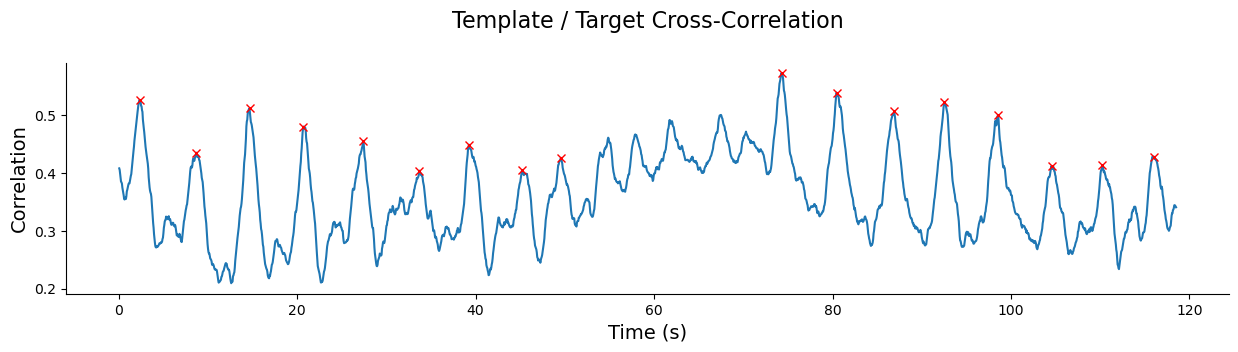

In [12]:
#BOWHEAD 

adj = 20

# load wav file and downsample
s, fs = sound.load("targets/bowhead_target.wav")
Sxx_target, tn_target, fn_target, ext_target = sound.spectrogram(s, fs, nperseg=1024, noverlap=512)

Sxx_target_dB = util.power2dB(Sxx_target) + adj


s, fs = sound.load("templates/bowhead_template.wav")
Sxx_template, tn_template, fn_template, ext_template = sound.spectrogram(s, fs, nperseg=1024, noverlap=512)

Sxx_template_dB = util.power2dB(Sxx_template) + adj


xcorrcoef, _  = rois.template_matching(Sxx_target_dB, Sxx_template_dB, 
                       tn_target, ext_target, 
                       peak_th = None,
                       display=False)

peaks, properties = find_peaks(xcorrcoef, prominence=0.11)  # adjust as needed

peak_times = tn_target[peaks]

fig, ax = plt.subplots(figsize=(15,3))
ax.plot(tn_target, xcorrcoef, label='Cross-correlation')
ax.plot(tn_target[peaks], xcorrcoef[peaks], 'rx', label='Peaks')
ax.set_xlabel("Time (s)", fontsize=14)
ax.set_ylabel("Correlation", fontsize=14)
ax.set_title("Template / Target Cross-Correlation\n", fontsize=16)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)



plt.savefig("crosscorr.jpg", dpi=300, bbox_inches="tight")

plt.show()

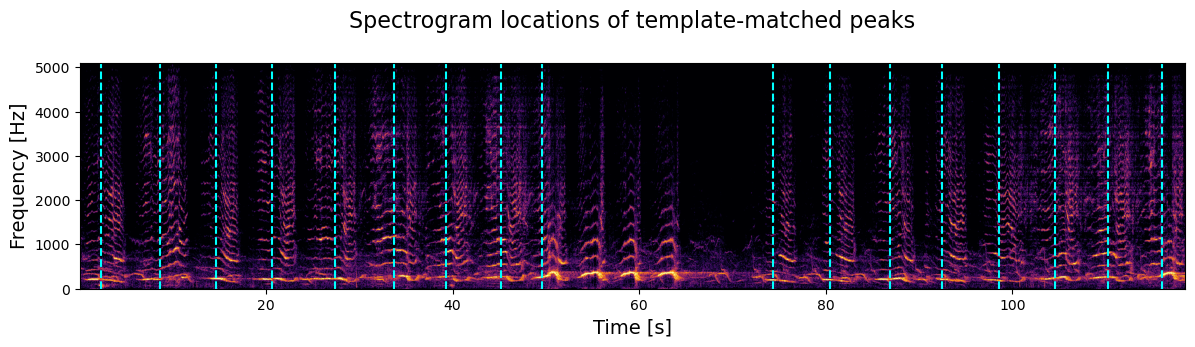

In [11]:
fig, ax = plt.subplots(figsize=(12, 3))
util.plot2d(Sxx_target_dB, extent=ext_target, ax=ax, cmap='inferno', colorbar=False, vmin=-50, vmax=0)
ax.set_title("Spectrogram locations of template-matched peaks\n", fontsize=16)
ax.set_xlabel("Time [s]", fontsize=14)
ax.set_ylabel("Frequency [Hz]", fontsize=14)

# Overlay vertical lines at detected peaks
for t in peak_times:
    ax.axvline(t, color='cyan', linestyle='--', linewidth=1.5)

plt.savefig("template-matched-spectro.jpg", dpi=300, bbox_inches="tight")
plt.show()



In [72]:
# original waveform and sampling rate

clip_duration = 5
half_clip = clip_duration / 2

s, fs = sound.load("ohw25_proj_RiptideRemix/contributor_folders/mattie/bowhead_target.wav")

# folder to save clips
#os.makedirs("ohw25_proj_RiptideRemix/contributor_folders/mattie/roi_clips", exist_ok=True)

min_t = peak_times[1] - half_clip
max_t = peak_times[1] + half_clip

sliced = sound.trim(s, fs, min_t = min_t, max_t = max_t)

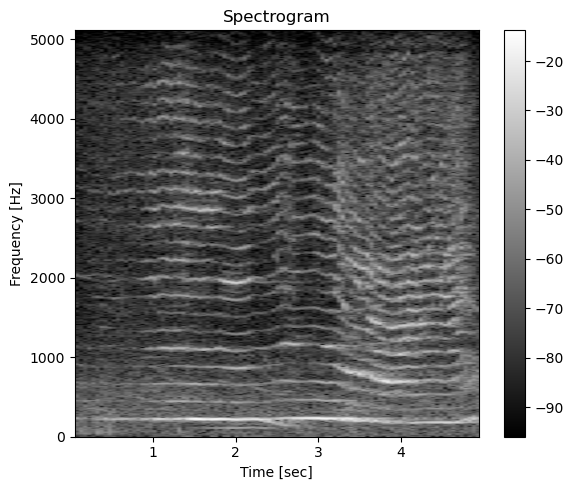

In [73]:
_ = sound.spectrogram(sliced, fs, display=True, figsize=(4,6))

In [74]:
sound.write('ohw25_proj_RiptideRemix/contributor_folders/mattie/roi_clips/bowhead_clip.wav', 
            fs, sliced, bit_depth=16)

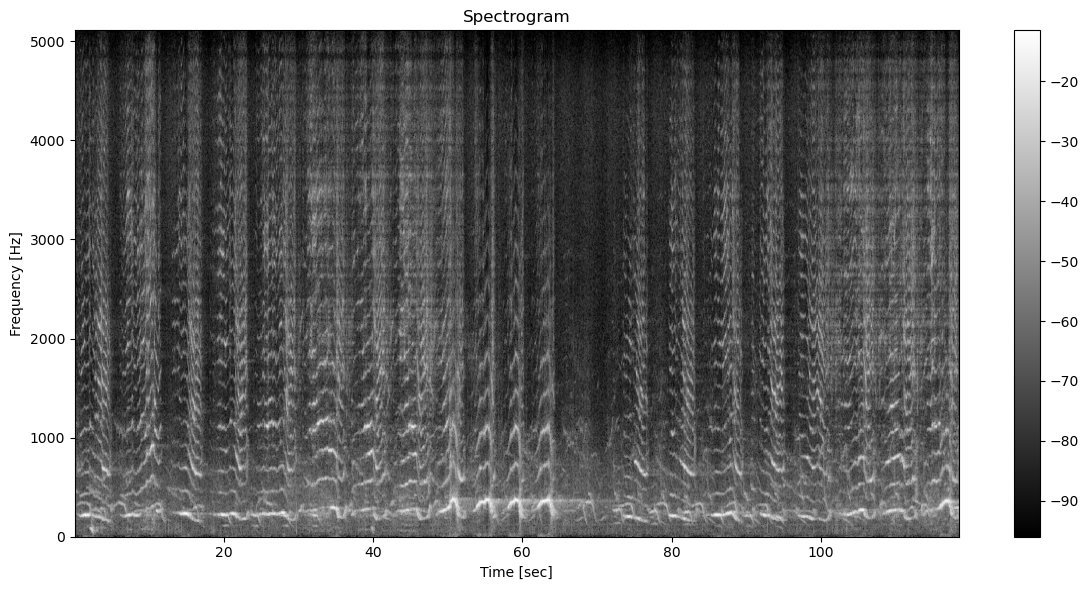

In [41]:
s, fs = sound.load("targets/bowhead_target.wav")
_ = sound.spectrogram(s, fs, nperseg=1024, noverlap=512, display=True, figsize = (5,12))

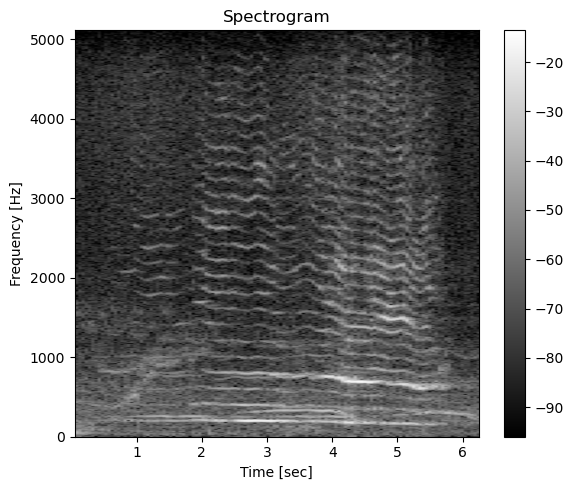

In [39]:
s, fs = sound.load("templates/bowhead_template.wav")
_ = sound.spectrogram(s, fs, nperseg=1024, noverlap=512, display=True, figsize = (4,6))